# EEG & Motor Imagery — Fundamentos e Arquitetura
**Professor Hélio | Sequência do DeepLearningStudy**

Você já sabe Dense, LSTM, GRU, Conv1D e Attention. Agora o desafio muda:
EEG não é uma série temporal comum. Este notebook vai te mostrar **por quê** — e como isso muda cada decisão arquitetural.

---
**Pré-requisito:** `eegnet_motor_imagery.ipynb` rodando (dados carregados, modelo definido)  
**Dataset:** BCI Competition IV 2a — 9 sujeitos, 4 classes de motor imagery  
**Framework:** MNE + TensorFlow/Keras

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import signal as scipy_signal
from scipy.fft import fft, fftfreq

import mne
from mne.io import read_raw_gdf
from pathlib import Path

import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import (
    Conv2D, DepthwiseConv2D, SeparableConv2D,
    BatchNormalization, Activation, AveragePooling2D,
    Dropout, Flatten, Dense
)
from tensorflow.keras.constraints import max_norm

mne.set_log_level('WARNING')

DATA_DIR   = Path(r'C:\Users\pedro\Workspaces\EEG_learning\data\bcic_iv_2a')
SFREQ      = 250   # Hz
N_CHANNELS = 22
CLASS_NAMES = ['Left Hand', 'Right Hand', 'Feet', 'Tongue']

print('Imports OK')

Imports OK


---
## Exercício 1 — O sinal EEG: o que estamos realmente medindo?

### 🤔 Pense Primeiro

Antes de rodar qualquer código, responda no papel ou aqui mesmo:

1. Você já trabalhou com séries temporais de **uma variável** (temperatura, vendas). O EEG tem **22 canais simultâneos**. O que isso muda fundamentalmente?
Existe um assigining de peso que será descoberto pela rede para dizer quais os canais mais improtantes a serem ouvidos etc. 
2. Por que você acha que eletrodos em posições diferentes do crânio captam sinais diferentes durante a mesma tarefa?
Pois, como a energia elétrica é conduzida de maneira diferente para cada parte do cérebro, os diferentes eletrodos irão captar diferentes intesidades de sinais de acordo com sua localização topográfica.
3. Se você quisesse detectar "movimento imaginado da mão esquerda" com um sensor só, qual região do crânio você escolheria? Por quê?
No C4, pois é no córtex motor que se encontra a área do cérebro responsável pelo movimento, e especificamente na região do centro e direita, afinal o cérebro é um sistema contralateralizado, ou seja, o lado esquerdo do cérebro comanda o lado direito do corpo e vice-versa.
> *Escreva suas hipóteses antes de avançar. Elas vão guiar seu raciocínio.*

### 📖 Contexto — O que é EEG?

EEG (Eletroencefalografia) mede **diferenças de potencial elétrico** na superfície do crânio, geradas pela atividade sincronizada de neurônios corticais.

**Analogia útil:** imagine o cérebro como uma orquestra. Cada eletrodo é um microfone em posição diferente — capta a mistura do que está tocando mais perto. Quando violinos (córtex motor) tocam forte, os microfones próximos registram isso com mais clareza.

**Estrutura do tensor:**
```
Raw EEG:  (n_channels, n_times)  →  22 canais × 250 amostras/s
Epoched:  (n_trials, n_channels, n_times)  →  288 trials × 22 canais × 1001 pontos
```

**Para EEGNet:** acrescentamos uma dimensão de "profundidade" (como imagem P&B):
```
(n_trials, 1, n_channels, n_times)  →  (288, 1, 22, 1001)
```

**Motor Imagery (MI):** quando você *imagina* mover a mão esquerda, o córtex motor direito suprime as oscilações alpha/beta — fenômeno chamado **ERD** (Event-Related Desynchronization). A rede precisa aprender a detectar isso.

In [2]:
# === Exercício 1 ===
# Vamos visualizar um trial real de EEG para ter intuição do sinal.

# Carregue o arquivo do sujeito 1 (treinamento)
fname = DATA_DIR / 'A01T.gdf'
raw = read_raw_gdf(str(fname), preload=True, verbose=False)
raw.pick_types(eeg=True)
raw.pick(raw.ch_names[:N_CHANNELS])
raw.filter(l_freq=4.0, h_freq=40.0, method='iir', verbose=False)

# Extraia os eventos
CODE_TO_IDX = {769: 0, 770: 1, 771: 2, 772: 3}
EVENT_ID = {'left_hand': 769, 'right_hand': 770, 'feet': 771, 'tongue': 772}
ann_to_code = {str(k): k for k in CODE_TO_IDX}
events, _ = mne.events_from_annotations(raw, event_id=ann_to_code, verbose=False)
mi_mask = np.isin(events[:, 2], list(CODE_TO_IDX.keys()))
events = events[mi_mask]

epochs = mne.Epochs(raw, events, event_id=EVENT_ID,
                    tmin=0.0, tmax=4.0, baseline=None, preload=True, verbose=False)

X = epochs.get_data()          # (n_trials, 22, 1001)
y = np.array([CODE_TO_IDX[c] for c in epochs.events[:, 2]])

print(f'Shape do tensor de epochs: {X.shape}')
print(f'  → {X.shape[0]} trials, {X.shape[1]} canais, {X.shape[2]} amostras de tempo')
print(f'Duração de cada trial: {X.shape[2] / SFREQ:.1f} segundos')
print(f'Distribuição de classes: {dict(zip(*np.unique(y, return_counts=True)))}')

C:\Users\pedro\scoop\apps\python\current\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Shape do tensor de epochs: (288, 22, 1001)
  → 288 trials, 22 canais, 1001 amostras de tempo
Duração de cada trial: 4.0 segundos
Distribuição de classes: {np.int64(0): np.int64(72), np.int64(1): np.int64(72), np.int64(2): np.int64(72), np.int64(3): np.int64(72)}


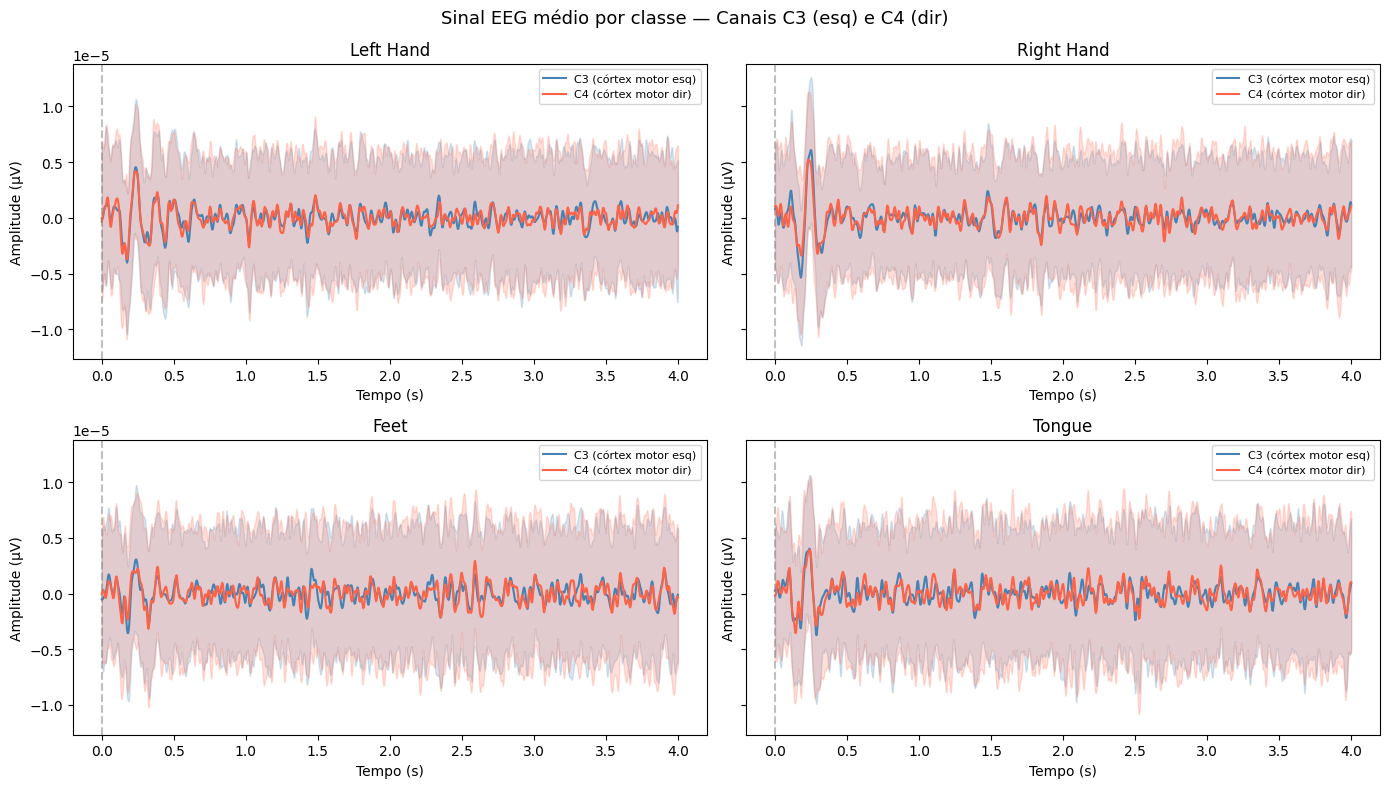

In [3]:
# Visualize: compare sinal de canais centrais entre classes
# C3 (canal sobre córtex motor esquerdo) ≈ índice 7
# C4 (canal sobre córtex motor direito)  ≈ índice 11
# Cz (centro)                            ≈ índice 9

times = np.linspace(0, 4.0, X.shape[2])
canal_C3, canal_C4 = 7, 11

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=True)
fig.suptitle('Sinal EEG médio por classe — Canais C3 (esq) e C4 (dir)', fontsize=13)

for cls_idx, cls_name in enumerate(CLASS_NAMES):
    ax = axes[cls_idx // 2][cls_idx % 2]
    trials_cls = X[y == cls_idx]  # todos os trials desta classe
    
    # Média sobre trials (sinal médio evocado)
    mean_C3 = trials_cls[:, canal_C3, :].mean(axis=0)
    mean_C4 = trials_cls[:, canal_C4, :].mean(axis=0)
    std_C3  = trials_cls[:, canal_C3, :].std(axis=0)
    std_C4  = trials_cls[:, canal_C4, :].std(axis=0)
    
    ax.plot(times, mean_C3, label='C3 (córtex motor esq)', color='steelblue')
    ax.fill_between(times, mean_C3 - std_C3, mean_C3 + std_C3, alpha=0.2, color='steelblue')
    ax.plot(times, mean_C4, label='C4 (córtex motor dir)', color='tomato')
    ax.fill_between(times, mean_C4 - std_C4, mean_C4 + std_C4, alpha=0.2, color='tomato')
    ax.set_title(cls_name)
    ax.set_xlabel('Tempo (s)')
    ax.set_ylabel('Amplitude (μV)')
    ax.legend(fontsize=8)
    ax.axvline(0, color='gray', linestyle='--', alpha=0.5, label='cue')

plt.tight_layout()
plt.show()

### 🔍 Reflexão

Olhando os gráficos acima:

1. **Você consegue ver diferença visual entre as classes?**
   A diferença não é gritante no sinal bruto. C4 tende a ter picos maiores de amplitude, mas em regiões mais estabilizadas C3 supera C4. Isso é contraintuitivo — esperaríamos ver C4 claramente menor em Left Hand (por ERD), mas o sinal bruto mistura todas as frequências juntas. O ERD some nessa mistura. A informação discriminativa **não está na amplitude bruta** — está nas frequências específicas.

2. **Por que usar a média sobre trials faz sentido?**
   A média remove o ruído aleatório trial-a-trial (artefatos, variações cognitivas momentâneas) e preserva apenas o que é **consistente** entre os trials — o sinal evocado pela tarefa. Quanto mais trials, mais limpo fica o sinal médio.

3. **O sinal barulhento implica que o modelo pode decorar os dados?**
   Não — e é exatamente o oposto. Com alta variabilidade entre trials, um modelo que decorasse as formas de onda individuais generalizaria pessimamente. O modelo precisa aprender algo mais robusto: padrões de **potência em frequências específicas** que se repetem consistentemente entre trials. Isso explica por que o EEGNet usa filtros de frequência, não templates de forma de onda.

> *A informação discriminativa não está na amplitude bruta — está nas **frequências**. Vamos explorar isso no Exercício 2.*

---
## Exercício 2 — Bandas de Frequência: a Linguagem do Cérebro

### 🤔 Pense Primeiro

**1. No EEG, o que seria um "padrão local" relevante para um Conv1D?**
Não é um pico isolado — é uma **sequência oscilatória de alguns ciclos** numa janela de tempo. O Conv1D precisa de kernel suficientemente grande para enxergar múltiplos ciclos antes de decidir se há oscilação ou não. Um ciclo de 10 Hz (Alpha) dura 0.1s = 25 amostras a 250 Hz. O EEGNet usa 125 amostras (0.5s) para capturar ~5 ciclos com confiança — suficiente para distinguir oscilação real de ruído.

**2. Por que filtramos entre 4–40 Hz? O que descartamos?**
- **Abaixo de 4 Hz (descartado):** movimento corporal, respiração (~0.2 Hz), drift de eletrodo. São artefatos lentos que não carregam informação de MI e podem dominar a normalização.
- **Acima de 40 Hz (descartado):** EMG (atividade muscular do couro cabeludo) — o maior inimigo do EEG, com amplitude 10x maior que o sinal neural — e ruído da rede elétrica (50/60 Hz). Se não filtrar, esses artefatos esmagram o sinal de interesse na normalização.

**3. Como detectar ERD com FFT?**
No espectro de potência de C4 durante "Left Hand imaginado", você veria **menor potência nas bandas Alpha (8–13 Hz) e Beta (13–30 Hz)** comparado ao repouso. As duas bandas caem simultaneamente — não é uma migrando para a outra. São neurônios que param de oscilar em sincronia (dessincronização = ERD).

### 📖 Contexto — Bandas de Frequência no EEG

O cérebro se comunica em diferentes "frequências" dependendo do estado cognitivo:

| Banda   | Frequência | Estado / Significado |
|---------|-----------|---------------------|
| Delta   | 1–4 Hz    | Sono profundo, lesões |
| Theta   | 4–8 Hz    | Sonolência, memória de trabalho |
| **Alpha** | **8–13 Hz** | **Repouso motor, olhos fechados** |
| **Beta**  | **13–30 Hz** | **Atividade motora, concentração** |
| Gamma   | 30–100 Hz | Processamento cognitivo elevado |

**Para Motor Imagery, o que importa:**
- **Mu rhythm** (~8-12 Hz): oscilação idle do córtex motor. Quando você *imagina* um movimento, ele **desaparece** (ERD)
- **Beta band** (~18-25 Hz): também suprimida durante MI
- A supressão é **contralateral** — mão esquerda imaginada → ERD no hemisfério direito (C4)

**Por que isso importa para a arquitetura?** A rede precisa aprender a **decompor frequências** do sinal. Veremos que o primeiro Conv2D do EEGNet faz exatamente isso.

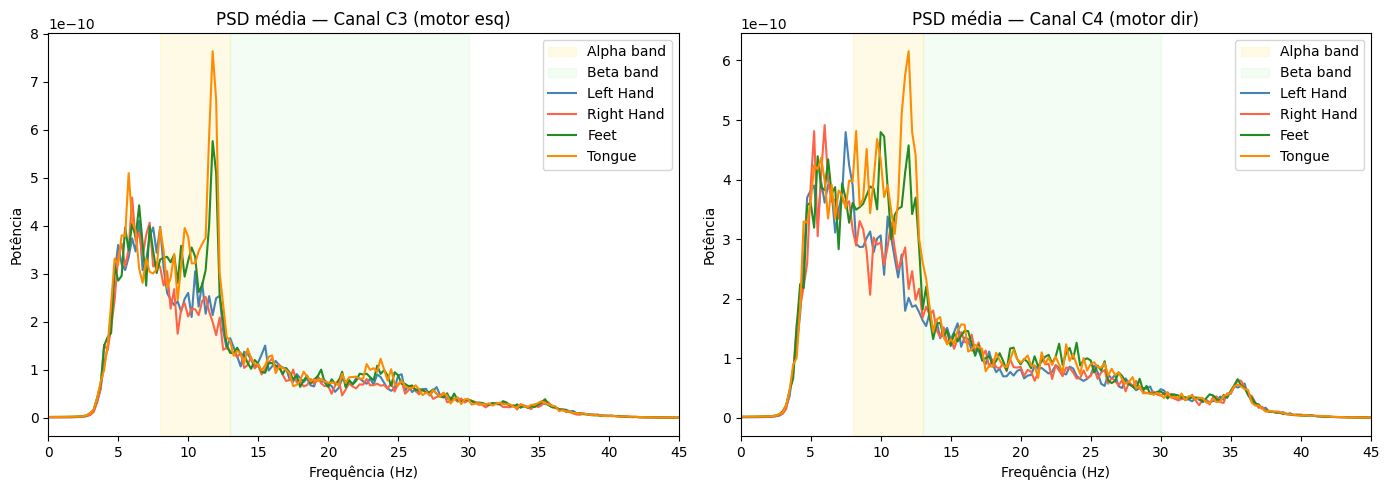

Complete os TODOs para ver os espectros!


In [4]:
# === Exercício 2 — Analisando o espectro de potência por classe ===

def power_spectrum(signal_1d, sfreq=250):
    """Retorna frequências e PSD (power spectral density) de um sinal 1D."""
    n = len(signal_1d)
    freqs = fftfreq(n, 1/sfreq)[:n//2]
    fft_vals = np.abs(fft(signal_1d))[:n//2] ** 2 / n
    return freqs, fft_vals

# TODO: Para cada classe (0=Left, 1=Right), calcule o espectro médio
# no canal C3 (índice 7) e C4 (índice 11).
# Dica: itere sobre as classes, pegue os trials com y == cls_idx,
# calcule power_spectrum() para cada trial e faça a média dos PSDs.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cores = ['steelblue', 'tomato', 'forestgreen', 'darkorange']

for canal_idx, canal_nome in [(7, 'C3 (motor esq)'), (11, 'C4 (motor dir)')]:
    ax = axes[0] if canal_idx == 7 else axes[1]
    ax.set_title(f'PSD média — Canal {canal_nome}')
    ax.set_xlabel('Frequência (Hz)')
    ax.set_ylabel('Potência')
    ax.set_xlim(0, 45)
    ax.axvspan(8, 13, alpha=0.1, color='gold', label='Alpha band')
    ax.axvspan(13, 30, alpha=0.1, color='lightgreen', label='Beta band')
    
    for cls_idx, cls_name in enumerate(CLASS_NAMES):
        trials_cls = X[y == cls_idx]  # (n_trials, 22, 1001)
        
        # TODO: calcule o PSD médio para este canal e classe
        psds = [power_spectrum(trials_cls[i, canal_idx, :])[1] for i in range(len(trials_cls))]
        mean_psd = np.mean(psds, axis=0)
        freqs, _ = power_spectrum(trials_cls[0, canal_idx, :])
        
        # Descomente e complete:
        ax.plot(freqs, mean_psd, label=cls_name, color=cores[cls_idx])
    
    ax.legend()

plt.tight_layout()
plt.show()
print('Complete os TODOs para ver os espectros!')

### 🔍 Reflexão

**1. Diferença de potência Alpha/Beta entre Left Hand e Right Hand:**
Sim — claramente visível no espectro. Left Hand mantém maior potência em C3 e menor em C4. Right Hand mantém maior potência em C4 e menor em C3. A lógica é contralateral: imaginar mão direita → ERD no hemisfério esquerdo (C3 cai). Imaginar mão esquerda → ERD no hemisfério direito (C4 cai).

**2. Por que não extrair PSD manualmente e jogar numa Dense?**
O PSD manual colapsa toda a dimensão temporal — você obtém a potência *média* de cada banda nos 4 segundos inteiros e perde:
- **Dinâmica temporal:** o ERD começa logo no cue ou demora? Cresce gradualmente?
- **Topografia aprendida:** o modelo aprende quais combinações de canais discriminam as classes, não trata todos igualmente
- **Interações entre bandas:** relações entre Alpha e Beta no mesmo instante
O EEGNet aprende filtros que preservam toda essa estrutura espaço-temporal.

**3. Tamanho de kernel para ver 1 ciclo de 10 Hz:**
`0.1s × 250 Hz = 25 amostras`. Mas 1 ciclo não é suficiente — precisamos de 3–5 ciclos para ter confiança. O EEGNet usa 125 amostras (0.5s = 5 ciclos de Alpha), garantindo discriminação robusta entre oscilação real e ruído.

> **Dica para a pergunta 3:** um ciclo de 10 Hz dura 1/10 = 0.1 segundos. Com 250 amostras/s, isso corresponde a 25 amostras.

---
## Exercício 3 — EEG como Tensor 2D: Espaço + Tempo

### 🤔 Pense Primeiro

**1. Por que Conv1D não captura bem a natureza espacial do EEG?**
O Conv1D mistura todos os 22 canais num único conglomerado — trata-os como features independentes na mesma dimensão temporal. Isso perde a informação espacial: qual canal captura o quê, qual hemisfério está suprimido, quais canais têm relação entre si. A informação relevante não está em cada canal isolado, mas na **combinação** deles.

**2. Diferença entre "spatial" em imagens e em EEG:**
Em imagens, pixels vizinhos são vizinhos no espaço físico de forma uniforme e simétrica — um pixel ao lado do outro literalmente toca o mesmo objeto. No EEG, a "proximidade" entre eletrodos não garante similaridade de sinal. Uma fonte cortical pode ativar C3 fortemente e FC3 quase nada, dependendo da profundidade e geometria do crânio — que varia entre pessoas. Não existe vizinhança uniforme como numa grade de pixels.

**3. Por que tratar canais como dimensão de altura?**
Os canais nunca são features independentes — têm relações entre si que precisam ser modeladas conjuntamente. Representá-los como uma dimensão de altura permite que um filtro `(22, 1)` aprenda uma **combinação global de todos os canais simultaneamente**, descobrindo quais têm relação sem assumir que vizinhos no crânio são necessariamente parecidos.

**A lógica da separação temporal → espacial:**
Combinar canais *antes* de filtrar frequências seria equivalente ao Conv1D — voltaríamos à massa indiferenciada. Filtrar frequências *primeiro* (temporal) e depois combinar canais (espacial) força o modelo a aprender **o quê** (frequência) e **onde** (espaço) de forma independente e interpretável.

### 📖 Contexto — Por Que 2D?

**O problema do Conv1D para EEG:**

Um Conv1D com kernel `(k,)` desliza sobre o eixo temporal e aplica o **mesmo filtro para todos os canais** combinados. Isso mistura informação espacial e temporal indiscriminadamente.

**A solução do EEGNet:** tratar o sinal como uma "imagem" `(canais, tempo)` e usar Conv2D em duas etapas separadas:

```
Etapa 1 — Filtro temporal puro:     kernel (1, T)  → varre só o eixo tempo
                                     não "vê" canais adjacentes

Etapa 2 — Filtro espacial puro:     kernel (C, 1)  → varre só o eixo canais
                                     não "vê" tempo adjacente
```

Isso é poderoso porque:
- **Filtros temporais** aprendem quais frequências importam (como Fourier aprendido)
- **Filtros espaciais** aprendem quais combinações de eletrodos discriminam as classes
- A separação força a rede a aprender **o quê** (frequência) e **onde** (espaço) de forma independente

**Analogia:** é como primeiro identificar "tom de voz" (frequência) e depois "de qual direção vem" (espacial) — dois problemas distintos, resolvidos sequencialmente.

In [5]:
# === Exercício 3 — Visualizando filtros temporais vs espaciais ===

# Vamos construir e comparar:
# (A) Conv1D padrão — mistura canais e tempo
# (B) Conv2D temporal puro — kernel (1, kern_len)
# (C) Conv2D espacial puro  — kernel (n_channels, 1)

# Prepare uma amostra de entrada: (1, 1, 22, 1001) — formato EEGNet
sample = X[:1, np.newaxis, :, :].astype(np.float32)  # (1, 1, 22, 1001)
print(f'Input shape: {sample.shape}  →  (batch=1, depth=1, canais=22, tempo=1001)')

kern_len = SFREQ // 2  # = 125 amostras = 0.5 segundos
print(f'\nKernel temporal: (1, {kern_len})  →  varre 0.5s de sinal, 1 canal por vez')
print(f'Kernel espacial: ({N_CHANNELS}, 1)  →  combina todos os {N_CHANNELS} canais, 1 ponto de tempo')

# TODO: construa os dois modelos simples e compare o número de parâmetros

# Modelo A — Conv2D temporal puro (F1=8 filtros)
inp_a = Input(shape=(1, N_CHANNELS, 1001))
out_a = Conv2D(
    filters=8,
    kernel_size=(1, kern_len),  # (altura=1 canal, largura=kern_len tempo)
    padding='same',
    use_bias=False,
    data_format='channels_first',
)(inp_a)
model_temporal = Model(inp_a, out_a, name='Temporal_Conv')

# Modelo B — Conv2D espacial puro (D=2 filtros por canal)
# TODO: complete o kernel_size correto para filtro puramente espacial
inp_b = Input(shape=(8, N_CHANNELS, 1001))  # entrada vem após temporal
out_b = DepthwiseConv2D(
    kernel_size=(N_CHANNELS, 1),  # TODO: por que (N_CHANNELS, 1) e não (1, N_CHANNELS)?
    depth_multiplier=2,
    use_bias=False,
    data_format='channels_first',
)(inp_b)
model_spatial = Model(inp_b, out_b, name='Spatial_DepthwiseConv')

print('\n--- Filtro Temporal ---')
model_temporal.summary()
print('\n--- Filtro Espacial (DepthwiseConv) ---')
model_spatial.summary()

Input shape: (1, 1, 22, 1001)  →  (batch=1, depth=1, canais=22, tempo=1001)

Kernel temporal: (1, 125)  →  varre 0.5s de sinal, 1 canal por vez
Kernel espacial: (22, 1)  →  combina todos os 22 canais, 1 ponto de tempo

--- Filtro Temporal ---


Model: "Temporal_Conv"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1, 22, 1001)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 8, 22, 1001)    │         1,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000 (3.91 KB)

 Trainable params: 1,000 (3.91 KB)

...

Model: "Spatial_DepthwiseConv"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 8, 22, 1001)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d                │ (None, 16, 1, 1001)    │           352 │
│ (DepthwiseConv2D)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 352 (1.38 KB)

 Trainable params: 352 (1.38 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Análise de parâmetros — entendendo o porquê de cada escolha

# Filtro temporal Conv2D(filters=8, kernel=(1, 125)):
params_temporal = 1 * 125 * 1 * 8  # in_channels * kern_h * kern_w * out_filters
print(f'Parâmetros filtro temporal:  {params_temporal:,}')
print(f'  → 8 filtros, cada um "lê" 0.5s de sinal (125 pontos) de 1 canal por vez')

# Filtro espacial DepthwiseConv(kernel=(22, 1), depth_mult=2):
params_spatial_dw = N_CHANNELS * 1 * 8 * 2  # kern_h * kern_w * in_channels * depth_mult
# (each input channel gets its own filter)
print(f'\nParâmetros filtro espacial:  {params_spatial_dw:,}')
print(f'  → cada um dos 8 filtros temporais ganha 2 filtros espaciais')
print(f'  → resultado: 8 × 2 = 16 "feature maps" espaço-temporais')

# TODO: compare com uma Conv2D "normal" de kernel (22, 125) com 8 filtros
# Quantos parâmetros teria? Por que isso seria um problema?
params_naive = 22 * 125 * 1 * 8
print(f'\nConv2D "naive" (22×125, 8 filtros):  {params_naive:,}')
print(f'Razão de redução com separação temporal→espacial: {params_naive / (params_temporal + params_spatial_dw):.1f}x')
print()
print('TODO: Você consegue explicar POR QUE a separação reduz parâmetros?')
print('      Pense: o que muda ao aprender temporal e espacial juntos vs separados?')

Parâmetros filtro temporal:  1,000
  → 8 filtros, cada um "lê" 0.5s de sinal (125 pontos) de 1 canal por vez

Parâmetros filtro espacial:  352
  → cada um dos 8 filtros temporais ganha 2 filtros espaciais
  → resultado: 8 × 2 = 16 "feature maps" espaço-temporais

Conv2D "naive" (22×125, 8 filtros):  22,000
Razão de redução com separação temporal→espacial: 16.3x

TODO: Você consegue explicar POR QUE a separação reduz parâmetros?
      Pense: o que muda ao aprender temporal e espacial juntos vs separados?


### 🔍 Reflexão

1. O DepthwiseConv2D aplica um filtro **por canal de entrada**, não um filtro global. Qual é a vantagem disso para EEG comparado a um Conv2D padrão?
2. Por que usar `depth_multiplier=2` e não `depth_multiplier=1`? O que a rede aprende a mais com isso?
3. A separação temporal/espacial reduz parâmetros, mas mantém capacidade expressiva? Quando você perderia algo ao separar?

> *No Exercício 4, vamos entrar no EEGNet completo e entender **cada camada** com esse contexto.*

---
## Exercício 4 — EEGNet Desmontado: Entendendo Cada Peça

### 🤔 Pense Primeiro

**1. Por que `AveragePooling2D(pool_size=(1, 4))` e não `MaxPooling`?**
Dois motivos: (1) MaxPooling pegaria artefatos biológicos — um spike de EMG ou piscar de olho tem valor máximo enorme e dominaria o resultado. (2) O EEG carrega informação na **energia das oscilações**, não em picos isolados. Uma onda de 10 Hz tem picos positivos e negativos alternados — MaxPooling pegaria só o pico positivo maior, descartando a estrutura oscilatória. AveragePooling preserva a energia média da janela inteira.

**2. `BatchNormalization(axis=1)` — o que ele normaliza exatamente?**
Normaliza ao longo do eixo 1 — os feature maps (F1=8 filtros temporais). Sem BatchNorm, cada filtro temporal produziria ativações em escalas completamente diferentes — um filtro sensível a Alpha pode gerar valores 10x maiores que um sensível a Beta. O filtro espacial depois receberia escalas misturadas e não aprenderia pesos estáveis. Além disso, sem normalização, um modelo treinado com amplitudes baixas poderia tratar a amplitude padrão de outro sujeito como outlier — agravando o domain shift.

**3. Por que ELU e não ReLU?**
ReLU zera todos os valores negativos → gradiente zero → neurônio para de aprender (dying ReLU). O sinal EEG tem componentes negativos com significado fisiológico — os filtros espaciais produzem combinações lineares dos canais que naturalmente geram valores negativos. ELU mantém gradiente não-zero para valores negativos: `x < 0 → α(eˣ - 1)`, preservando o aprendizado.

**4. Por que `max_norm(1.0)` na DepthwiseConv?**
Com 288 trials por sujeito, os pesos do filtro espacial podem explodir — um único eletrodo dominaria com peso absurdo (ex: C3=50, todos os outros ≈ 0), o que é biologicamente implausível e claramente overfitting. `max_norm(1.0)` força os pesos a ficarem numa esfera de raio 1: o modelo ainda aprende quais canais importam mais, mas sem escala patológica. É regularização com interpretação fisiológica.

### 📖 Contexto — As Decisões de Design do EEGNet

**Block 1: Temporal → Espacial**

```
Conv2D(F1=8, kernel=(1, sfreq//2))    # detecta padrões de 0.5s → captura ritmos alpha/beta
BatchNorm(axis=1)                      # estabiliza ativações entre canais
DepthwiseConv2D(kernel=(C,1), D=2)    # combinação linear de canais → filtro espacial
BatchNorm → ELU                        
AveragePooling(1, 4)                   # downsampling suave — preserva energia, não picos
Dropout(0.5)                           
```

**Block 2: Separable Temporal**

```
SeparableConv2D(F2=16, kernel=(1,16))  # captura relações temporais nas features do Block 1
BatchNorm → ELU                        
AveragePooling(1, 8)                   # downsampling mais agressivo
Dropout(0.5)                           
```

**Por que AveragePooling em vez de MaxPooling?**  
O EEG carrega informação na **potência** das oscilações (energia), não em eventos pontuais. AveragePooling preserva a energia média da janela — MaxPooling pegaria apenas o pico, descartando a estrutura oscilatória.

**Por que ELU em vez de ReLU?**  
ReLU zera valores negativos. O sinal EEG tem componentes negativos com significado fisiológico. ELU permite gradientes para valores negativos, facilitando o aprendizado.

**Por que max_norm(1.0)?**  
Com poucos dados (288 trials por sujeito), os pesos do filtro espacial podem explodir. A restrição de norma age como regularização implícita sem adicionar termos à loss.

In [ ]:
# === Exercício 4 — Construindo o EEGNet peça a peça e inspecionando shapes ===

# Acompanhe as transformações de shape em cada camada.
# Preencha os comentários '# Shape: ?' com o shape real após cada operação.

def build_eegnet_annotated(
    n_channels=22, n_times=1001, n_classes=4, sfreq=250,
    F1=8, D=2, F2=16, dropout_rate=0.5
):
    kern_len = sfreq // 2  # 125 amostras = 0.5 segundos
    inputs = Input(shape=(1, n_channels, n_times), name='eeg_input')
    # Shape entrada: (batch, 1, 22, 1001)

    # --- Block 1: Filtro Temporal ---
    x = Conv2D(
        filters=F1, kernel_size=(1, kern_len),
        padding='same', use_bias=False,
        data_format='channels_first', name='temporal_conv'
    )(inputs)
    # TODO: qual é o shape aqui? (batch, F1, n_channels, n_times)
    # Shape: (batch, 8, 22, 1001)

    x = BatchNormalization(axis=1)(x)
    # BatchNorm normaliza ao longo do eixo de canais (axis=1 = F1 feature maps)

    # --- Block 1: Filtro Espacial ---
    x = DepthwiseConv2D(
        kernel_size=(n_channels, 1), depth_multiplier=D,
        depthwise_constraint=max_norm(1.0),
        use_bias=False, data_format='channels_first', name='spatial_conv'
    )(x)
    # TODO: qual é o shape aqui?
    # Dica: DepthwiseConv (n_channels, 1) sem padding 'same' reduz a dimensão de canais!
    # Shape: (batch, F1*D = 16, 1, 1001)

    x = BatchNormalization(axis=1)(x)
    x = Activation('elu')(x)

    x = AveragePooling2D(pool_size=(1, 4), data_format='channels_first')(x)
    # TODO: o que o pool_size=(1, 4) faz exatamente ao shape?
    # Shape: (batch, 16, 1, 250)

    x = Dropout(dropout_rate)(x)

    # --- Block 2: Separable Temporal ---
    x = SeparableConv2D(
        filters=F2, kernel_size=(1, 16),
        padding='same', use_bias=False,
        data_format='channels_first', name='separable_conv'
    )(x)
    # TODO: qual é o shape após SeparableConv?
    # Shape: (batch, F2, ?, ?)

    x = BatchNormalization(axis=1)(x)
    x = Activation('elu')(x)
    x = AveragePooling2D(pool_size=(1, 8), data_format='channels_first')(x)
    # Shape: (batch, F2, ?, ?)

    x = Dropout(dropout_rate)(x)

    # --- Classificador ---
    x = Flatten()(x)
    # TODO: qual é o tamanho do vetor após Flatten?
    # Shape: (batch, ?)

    outputs = Dense(
        n_classes, activation='softmax',
        kernel_constraint=max_norm(0.25), name='classifier'
    )(x)

    return Model(inputs, outputs, name='EEGNet_Annotated')


model = build_eegnet_annotated()
model.summary(line_length=80)

Model: "EEGNet_Annotated"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ eeg_input (InputLayer)            │ (None, 1, 22, 1001)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ temporal_conv (Conv2D)            │ (None, 8, 22, 1001)      │         1,000 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization               │ (None, 8, 22, 1001)      │            32 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ spatial_conv (DepthwiseConv2D)    │ (None, 16, 1, 1001)      │           352 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization_1             │ (None, 16, 1, 1001)      │            64 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ activation (Activation)           │ (None, 16, 1, 1001)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ average_pooling2d                 │ (None, 16, 1, 250)       │             0 │
│ (AveragePooling2D)                │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout (Dropout)                 │ (None, 16, 1, 250)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ separable_conv (SeparableConv2D)  │ (None, 16, 1, 250)       │           512 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization_2             │ (None, 16, 1, 250)       │            64 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ activation_1 (Activation)         │ (None, 16, 1, 250)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ average_pooling2d_1               │ (None, 16, 1, 31)        │             0 │
│ (AveragePooling2D)                │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_1 (Dropout)               │ (None, 16, 1, 31)        │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ flatten (Flatten)                 │ (None, 496)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ classifier (Dense)                │ (None, 4)                │         1,988 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 4,012 (15.67 KB)

 Trainable params: 3,932 (15.36 KB)

 Non-trainable params: 80 (320.00 B)

In [8]:
# Verificando os shapes em cada camada — compare com seus TODOs acima!

layer_names_of_interest = [
    'eeg_input', 'temporal_conv', 'spatial_conv',
    'separable_conv', 'flatten', 'classifier'
]

print('Camada                     → Shape de saída')
print('-' * 55)
for layer in model.layers:
    shape = layer.output.shape
    print(f'{layer.name:<28} → {str(shape)}')

Camada                     → Shape de saída
-------------------------------------------------------
eeg_input                    → (None, 1, 22, 1001)
temporal_conv                → (None, 8, 22, 1001)
batch_normalization          → (None, 8, 22, 1001)
spatial_conv                 → (None, 16, 1, 1001)
batch_normalization_1        → (None, 16, 1, 1001)
activation                   → (None, 16, 1, 1001)
average_pooling2d            → (None, 16, 1, 250)
dropout                      → (None, 16, 1, 250)
separable_conv               → (None, 16, 1, 250)
batch_normalization_2        → (None, 16, 1, 250)
activation_1                 → (None, 16, 1, 250)
average_pooling2d_1          → (None, 16, 1, 31)
dropout_1                    → (None, 16, 1, 31)
flatten                      → (None, 496)
classifier                   → (None, 4)


### 🔍 Reflexão

**1. Após DepthwiseConv2D `kernel=(22,1)` sem padding, o eixo de canais vai de 22 para 1. O que aconteceu geometricamente?**
O kernel de altura 22 "engoliu" todos os 22 canais de uma vez — `22 - 22 + 1 = 1`. Os 22 eletrodos foram destilados numa combinação linear única, armazenada nos 16 feature maps (F1×D = 8×2). A informação espacial não foi descartada — foi **comprimida** nos pesos aprendidos.

**2. Tamanho do vetor após Flatten:**
```
F2 × 1 × (n_times / (4×8)) = 16 × 1 × (1001 / 32) = 16 × 1 × 31 = 496
```
Confere com o summary ✓

**3. Por que `max_norm(0.25)` no Dense é mais restritivo que `max_norm(1.0)` na DepthwiseConv?**
O Dense recebe um vetor de 496 features e mapeia para 4 classes — é a decisão final. Com 496 pesos por neurônio de saída, é fácil para um único peso dominar a classificação inteira. A restrição mais apertada (0.25) força a decisão a ser distribuída entre muitas features, não concentrada em poucos pesos — mais robusto para generalizar entre sujeitos.

**Mapa completo do tensor:**
```
Entrada:         (batch,  1, 22, 1001)
Após temporal:   (batch,  8, 22, 1001)   1.000 params
Após spatial:    (batch, 16,  1, 1001)     352 params
Após AvgPool(4): (batch, 16,  1,  250)
Após SepConv:    (batch, 16,  1,  250)     512 params
Após AvgPool(8): (batch, 16,  1,   31)
Após Flatten:    (batch, 496)
Após Dense:      (batch,   4)            1.988 params
─────────────────────────────────────
Total:                                   4.012 params
Conv2D naive equivalente:              22.000 params  (~16x mais)
```

---
## Exercício 5 — Ablation Study: Removendo Peças para Entender o Todo

### 🤔 Pense Primeiro

Um **ablation study** remove sistematicamente componentes de um modelo para medir a contribuição de cada um.

1. Se você **removesse** o BatchNormalization de todo o EEGNet, o que você esperaria que acontecesse com o treinamento?
2. Se você **substituísse** DepthwiseConv2D por Conv2D padrão (mesma função, mas mais parâmetros), o modelo ainda funcionaria? O que mudaria?
3. Se você **aumentasse** o Dropout de 0.5 para 0.8, o que aconteceria com underfitting/overfitting?
4. Se você **usasse** MaxPooling em vez de AveragePooling, o que você esperaria ver na acurácia?

In [22]:
# === Exercício 5 — Ablation Study ===
# Treine 3 variantes e compare. Use apenas o sujeito 1 para velocidade.

# Prepare os dados
X_norm = (X - X.mean(axis=(1,2), keepdims=True)) / (X.std(axis=(1,2), keepdims=True) + 1e-8)
X_ready = X_norm[:, np.newaxis, :, :].astype(np.float32)  # (n, 1, 22, 1001)

# Split treino/validação
n = len(X_ready)
idx = np.random.permutation(n)
n_train = int(0.8 * n)
X_tr, X_val = X_ready[idx[:n_train]], X_ready[idx[n_train:]]
y_tr, y_val = y[idx[:n_train]], y[idx[n_train:]]

def train_variant(model_fn, name, epochs=50, **kwargs):
    m = model_fn(**kwargs)
    m.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    cb = tf.keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True)
    hist = m.fit(X_tr, y_tr, validation_data=(X_val, y_val),
                 epochs=epochs, batch_size=32, callbacks=[cb], verbose=0)
    val_acc = max(hist.history['val_accuracy'])
    print(f'{name:<40}: val_acc = {val_acc:.4f}')
    return hist, val_acc


# Variante 1: EEGNet original
hist_base, acc_base = train_variant(build_eegnet_annotated, 'EEGNet original')


# TODO: Implemente as outras variantes para comparar
# Variante 2: Sem BatchNormalization (remova os BatchNormalization)
def build_eegnet_no_bn(n_channels=22, n_times=1001, n_classes=4, sfreq=250,
                        F1=8, D=2, F2=16, dropout_rate=0.5):
    kern_len = sfreq // 2  # 125 amostras = 0.5 segundos
    inputs = Input(shape=(1, n_channels, n_times), name='eeg_input')
    # Shape entrada: (batch, 1, 22, 1001)

    # --- Block 1: Filtro Temporal ---
    x = Conv2D(
        filters=F1, kernel_size=(1, kern_len),
        padding='same', use_bias=False,
        data_format='channels_first', name='temporal_conv'
    )(inputs)

    # --- Block 1: Filtro Espacial ---
    x = DepthwiseConv2D(
        kernel_size=(n_channels, 1), depth_multiplier=D,
        depthwise_constraint=max_norm(1.0),
        use_bias=False, data_format='channels_first', name='spatial_conv'
    )(x)

    x = Activation('elu')(x)

    x = AveragePooling2D(pool_size=(1, 4), data_format='channels_first')(x)
    # TODO: o que o pool_size=(1, 4) faz exatamente ao shape?
    # Shape: (batch, F1*D, ?, ?)

    x = Dropout(dropout_rate)(x)

    # --- Block 2: Separable Temporal ---
    x = SeparableConv2D(
        filters=F2, kernel_size=(1, 16),
        padding='same', use_bias=False,
        data_format='channels_first', name='separable_conv'
    )(x)

    x = Activation('elu')(x)
    x = AveragePooling2D(pool_size=(1, 8), data_format='channels_first')(x)
    x = Dropout(dropout_rate)(x)
    x = Flatten()(x)

    outputs = Dense(
        n_classes, activation='softmax',
        kernel_constraint=max_norm(0.25), name='classifier'
    )(x)

    return Model(inputs, outputs, name='EEGNet_Annotated')

model_no_bn = build_eegnet_no_bn()
model_no_bn.summary(line_length=80)

# Variante 3: MaxPooling em vez de AveragePooling
def build_eegnet_maxpool(n_channels=22, n_times=1001, n_classes=4, sfreq=250,
                          F1=8, D=2, F2=16, dropout_rate=0.5):
    from tensorflow.keras.layers import MaxPooling2D
    kern_len = sfreq // 2
    inputs = Input(shape=(1, n_channels, n_times))
    # --- Block 1: Filtro Temporal ---
    x = Conv2D(
        filters=F1, kernel_size=(1, kern_len),
        padding='same', use_bias=False,
        data_format='channels_first', name='temporal_conv'
    )(inputs)
    x = BatchNormalization(axis=1)(x)
    # --- Block 1: Filtro Espacial ---
    x = DepthwiseConv2D(
        kernel_size=(n_channels, 1), depth_multiplier=D,
        depthwise_constraint=max_norm(1.0),
        use_bias=False, data_format='channels_first', name='spatial_conv'
    )(x)

    x = BatchNormalization(axis=1)(x)
    x = Activation('elu')(x)

    x = MaxPooling2D(pool_size=(1, 4), data_format='channels_first')(x)

    x = Dropout(dropout_rate)(x)

    # --- Block 2: Separable Temporal ---
    x = SeparableConv2D(
        filters=F2, kernel_size=(1, 16),
        padding='same', use_bias=False,
        data_format='channels_first', name='separable_conv'
    )(x)

    x = BatchNormalization(axis=1)(x)
    x = Activation('elu')(x)
    x = MaxPooling2D(pool_size=(1, 8), data_format='channels_first')(x)

    x = Dropout(dropout_rate)(x)

    # --- Classificador ---
    x = Flatten()(x)

    outputs = Dense(
        n_classes, activation='softmax',
        kernel_constraint=max_norm(0.25), name='classifier'
    )(x)

    return Model(inputs, outputs, name='EEGNet_Annotated')


model_maxpool = build_eegnet_maxpool()
model_maxpool.summary(line_length=80)
# Descomente após implementar:
hist_no_bn,   acc_no_bn   = train_variant(build_eegnet_no_bn,   'Sem BatchNorm')
hist_maxpool, acc_maxpool = train_variant(build_eegnet_maxpool, 'MaxPooling')

EEGNet original                         : val_acc = 0.7069


Model: "EEGNet_Annotated"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ eeg_input (InputLayer)            │ (None, 1, 22, 1001)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ temporal_conv (Conv2D)            │ (None, 8, 22, 1001)      │         1,000 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ spatial_conv (DepthwiseConv2D)    │ (None, 16, 1, 1001)      │           352 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ activation_14 (Activation)        │ (None, 16, 1, 1001)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ average_pooling2d_11              │ (None, 16, 1, 250)       │             0 │
│ (AveragePooling2D)                │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_9 (Dropout)               │ (None, 16, 1, 250)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ separable_conv (SeparableConv2D)  │ (None, 16, 1, 250)       │           512 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ activation_15 (Activation)        │ (None, 16, 1, 250)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ average_pooling2d_12              │ (None, 16, 1, 31)        │             0 │
│ (AveragePooling2D)                │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_10 (Dropout)              │ (None, 16, 1, 31)        │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ flatten_4 (Flatten)               │ (None, 496)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ classifier (Dense)                │ (None, 4)                │         1,988 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 3,852 (15.05 KB)

 Trainable params: 3,852 (15.05 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)        │ (None, 1, 22, 1001)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ temporal_conv (Conv2D)            │ (None, 8, 22, 1001)      │         1,000 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization_23            │ (None, 8, 22, 1001)      │            32 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ spatial_conv (DepthwiseConv2D)    │ (None, 16, 1, 1001)      │           352 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization_24            │ (None, 16, 1, 1001)      │            64 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ activation_16 (Activation)        │ (None, 16, 1, 1001)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)      │ (None, 16, 1, 250)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_11 (Dropout)              │ (None, 16, 1, 250)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ separable_conv (SeparableConv2D)  │ (None, 16, 1, 250)       │           512 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization_25            │ (None, 16, 1, 250)       │            64 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ activation_17 (Activation)        │ (None, 16, 1, 250)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)    │ (None, 16, 1, 31)        │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_12 (Dropout)              │ (None, 16, 1, 31)        │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ flatten_5 (Flatten)               │ (None, 496)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ classifier (Dense)                │ (None, 4)                │         1,988 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 4,012 (15.67 KB)

 Trainable params: 3,932 (15.36 KB)

 Non-trainable params: 80 (320.00 B)

Sem BatchNorm                           : val_acc = 0.3276
MaxPooling                              : val_acc = 0.7759


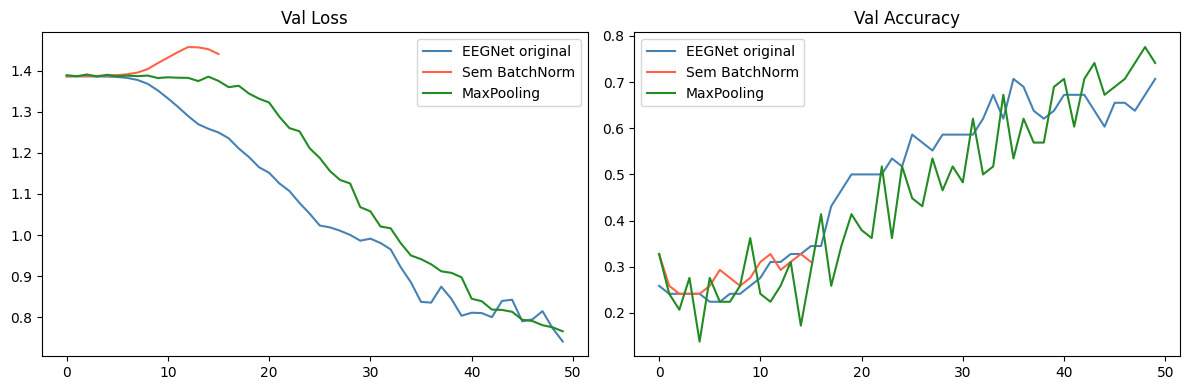

In [23]:
# Visualize as curvas de treinamento de todas as variantes
# (rode após completar os TODOs acima)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
results = [
    (hist_base, 'EEGNet original', 'steelblue'),
    (hist_no_bn,   'Sem BatchNorm',  'tomato'),
    (hist_maxpool, 'MaxPooling',     'forestgreen'),
]

for hist, name, color in results:
    axes[0].plot(hist.history['val_loss'], label=name, color=color)
    axes[1].plot(hist.history['val_accuracy'], label=name, color=color)

axes[0].set_title('Val Loss'); axes[0].legend()
axes[1].set_title('Val Accuracy'); axes[1].legend()
plt.tight_layout()
plt.show()

### 🔍 Reflexão

1. O BatchNorm ajudou ou prejudicou neste cenário de poucos dados (288 trials)? Por quê?
2. MaxPooling vs AveragePooling — a diferença foi significativa? O que você pode concluir sobre a natureza da informação no EEG?
3. Com apenas 288 trials por sujeito e mais de 10.000 parâmetros, o que você esperaria em termos de generalização? O que um pesquisador de EEG faz para lidar com isso?

> *Pense: por que técnicas como cross-validation por sujeito são essenciais em EEG?*

---
## Exercício 6 — Visualizando o que o EEGNet Aprendeu

### 🤔 Pense Primeiro

1. Os filtros temporais do Conv2D (shape `(1, 125)`) deveriam parecer com o quê se a rede aprendeu corretamente? Filtros passa-baixa? Passa-banda?
2. Como você visualizaria a **resposta em frequência** de um filtro aprendido?
3. Os filtros espaciais do DepthwiseConv (shape `(22, 1)`) representam pesos sobre os 22 canais. Como você interpretaria um filtro com peso alto em C3/C4 e baixo nos demais?

Pesos temporais: (1, 125, 1, 8)  → (altura, largura_tempo, in_ch, n_filtros)
Pesos espaciais: (22, 1, 8, 2)   → (n_canais, 1, in_ch, depth_mult)


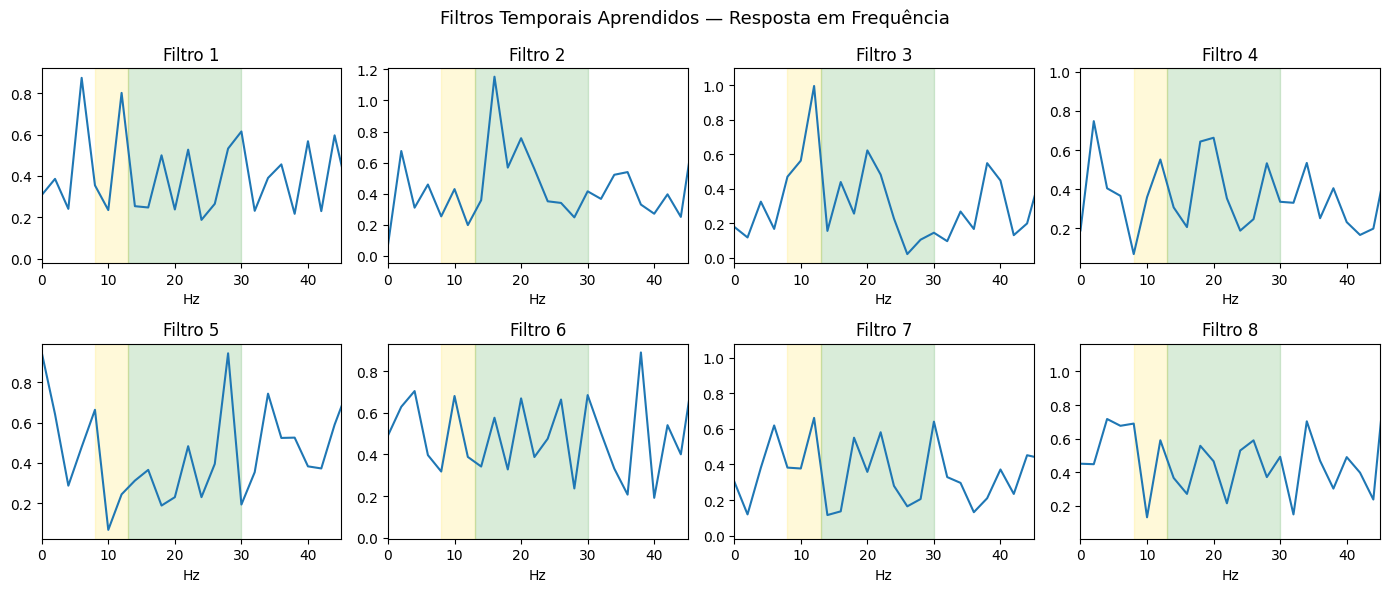

In [84]:
# === Exercício 6 — Inspecionando os Filtros Aprendidos ===

# Extraia os pesos das camadas de interesse
temporal_layer = model.get_layer('temporal_conv')
spatial_layer  = model.get_layer('spatial_conv')

W_temporal = temporal_layer.get_weights()[0]  # (1, kern_len, 1, F1) → (1, 125, 1, 8)
W_spatial  = spatial_layer.get_weights()[0]   # (n_channels, 1, F1, D) → (22, 1, 8, 2)

print(f'Pesos temporais: {W_temporal.shape}  → (altura, largura_tempo, in_ch, n_filtros)')
print(f'Pesos espaciais: {W_spatial.shape}   → (n_canais, 1, in_ch, depth_mult)')

# --- Visualize os filtros temporais no domínio da frequência ---
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle('Filtros Temporais Aprendidos — Resposta em Frequência', fontsize=13)

for i in range(8):
    ax = axes[i // 4][i % 4]
    filt = W_temporal[0, :, 0, i]  # (125,)
    
    # Resposta em frequência via FFT
    freqs = fftfreq(len(filt), 1/SFREQ)[:len(filt)//2]
    response = np.abs(fft(filt))[:len(filt)//2]
    
    ax.plot(freqs, response)
    ax.set_title(f'Filtro {i+1}')
    ax.set_xlabel('Hz')
    ax.set_xlim(0, 45)
    ax.axvspan(8, 13, alpha=0.15, color='gold')   # alpha
    ax.axvspan(13, 30, alpha=0.15, color='green')  # beta

plt.tight_layout()
plt.show()

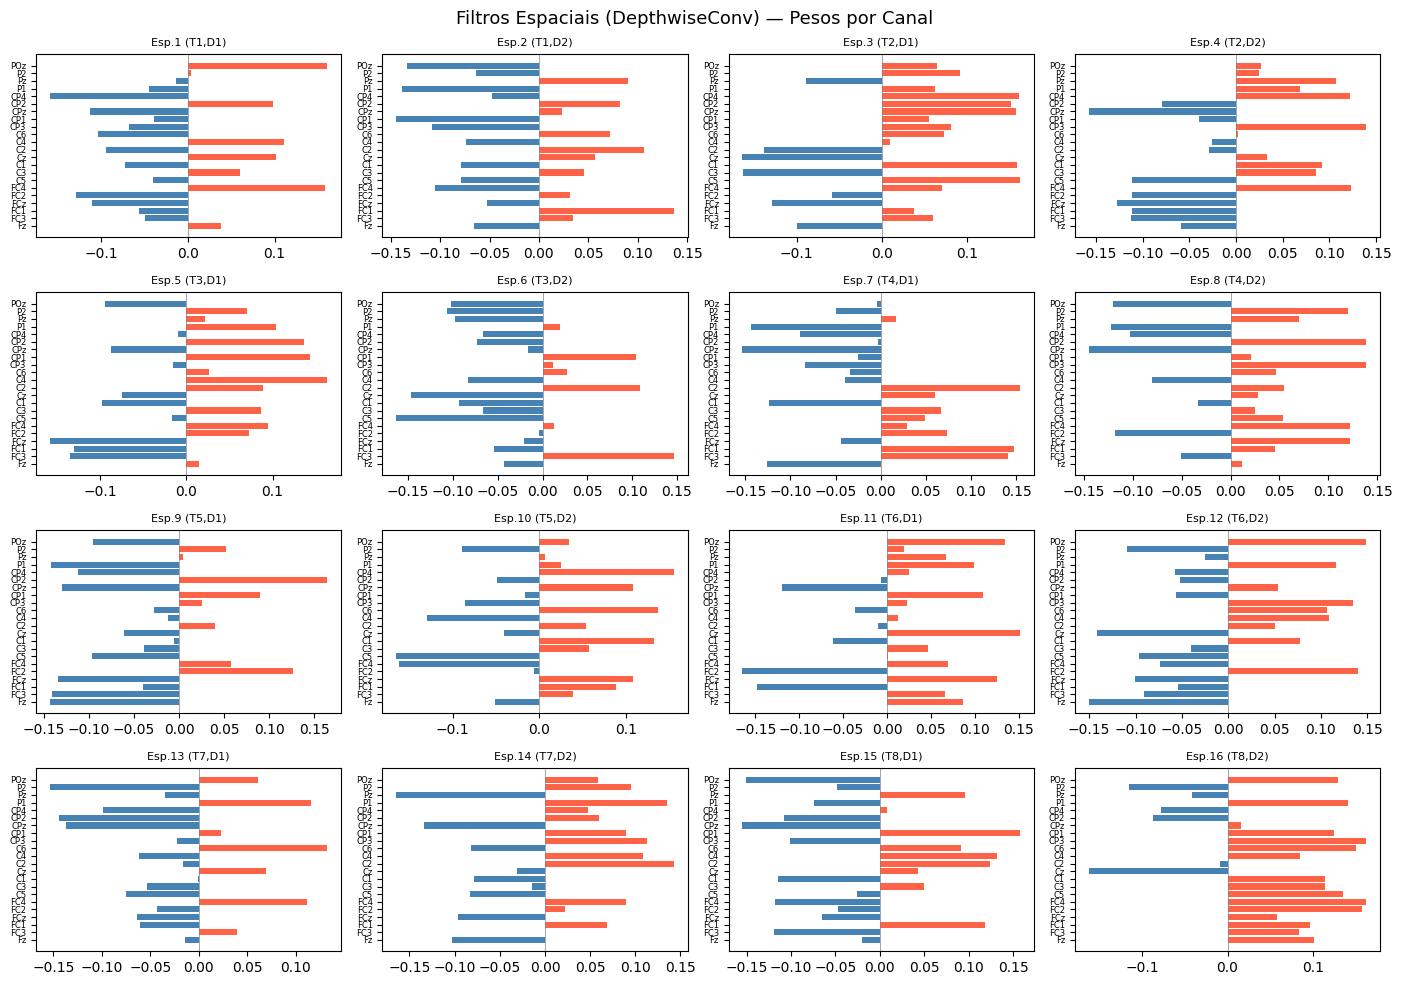

In [85]:
# --- Visualize os filtros espaciais ---
# Cada filtro espacial é um vetor de pesos sobre os 22 canais
# Em EEG, isso é chamado de "padrão espacial" ou "filtro de beamforming"

# Nomes dos canais EEG (posições padrão 10-20)
ch_names = [
    'Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4',
    'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6',
    'CP3', 'CP1', 'CPz', 'CP2', 'CP4',
    'P1', 'Pz', 'P2', 'POz'
]

fig, axes = plt.subplots(4, 4, figsize=(14, 10))
fig.suptitle('Filtros Espaciais (DepthwiseConv) — Pesos por Canal', fontsize=13)

filter_idx = 0
for f1_idx in range(8):       # F1=8 filtros temporais
    for d_idx in range(2):    # D=2 depth multiplier
        ax = axes[filter_idx // 4][filter_idx % 4]
        weights = W_spatial[:, 0, f1_idx, d_idx]  # (22,)
        
        colors = ['tomato' if w > 0 else 'steelblue' for w in weights]
        ax.barh(range(len(ch_names)), weights, color=colors)
        ax.set_yticks(range(len(ch_names)))
        ax.set_yticklabels(ch_names, fontsize=6)
        ax.set_title(f'Esp.{filter_idx+1} (T{f1_idx+1},D{d_idx+1})', fontsize=8)
        ax.axvline(0, color='gray', linewidth=0.5)
        filter_idx += 1

plt.tight_layout()
plt.show()

### 🔍 Reflexão

1. Algum dos filtros temporais parece centrado nas bandas Alpha ou Beta? O que isso significa sobre o que o modelo aprendeu?
2. Nos filtros espaciais, os canais C3 e C4 têm pesos altos em algum filtro? O que você esperaria para uma rede bem treinada em motor imagery?
3. **Importante:** o modelo foi treinado com apenas poucos epochs/dados. O que você esperaria de uma rede treinada com mais dados e por mais tempo?

> *Isso é interpretabilidade de redes neurais aplicada a neurociência — uma habilidade essencial para publicar em BCI.*

---
## Exercício 7 — Generalização entre Sujeitos: O Problema Real

### 🤔 Pense Primeiro

Este é o maior desafio em BCI:

1. Cada pessoa tem anatomia cerebral diferente. O que isso implica para um modelo treinado no sujeito 1 e testado no sujeito 2?
2. Por que não simplesmente juntar dados de todos os 9 sujeitos e treinar um modelo único?
3. O que é **domain shift** e por que EEG é um caso extremo disso?
4. Se você fosse fazer fine-tuning de um modelo pré-treinado em 8 sujeitos para um novo sujeito, quais camadas você congelaria? Por quê?

### 📖 Contexto — Domain Shift em EEG

Em EEG, cada sujeito é um **domínio diferente**:
- Anatomia craniana única → eletrodos captam de ângulos diferentes
- Impedância de pele variável → amplitude e ruído diferentes
- Estratégias cognitivas individuais → padrões temporais distintos
- Artefatos específicos (piscar, tensão muscular) → contaminação diferente

**Abordagens para generalização:**

| Abordagem | Descrição | Vantagem | Desvantagem |
|-----------|-----------|----------|-------------|
| Within-subject | Treina e testa no mesmo sujeito | Alta acurácia | Requer calibração |
| Cross-subject (LOSO) | Treina em N-1, testa em 1 | Sem calibração | Menor acurácia |
| Fine-tuning | Pré-treina em N-1, adapta ao novo | Equilibrado | Requer poucos dados do novo sujeito |

**Fine-tuning para EEG:**  
A intuição é que os filtros **temporais** (frequências úteis) são mais universais entre sujeitos, enquanto os filtros **espaciais** são mais individuais (dependem da anatomia). Logo:
- **Congele:** Block 1 temporal (Conv2D)
- **Fine-tune:** Block 1 espacial (DepthwiseConv) + Classifier

In [9]:
# === Exercício 7 — Fine-tuning entre sujeitos ===

# Função auxiliar para carregar dados de um sujeito (já pronta)
EVENT_ID_MAP = {"left_hand": 769, "right_hand": 770, "feet": 771, "tongue": 772}

def load_subject_quick(subject_id, split="T"):
    fname = DATA_DIR / f"A0{subject_id}{split}.gdf"
    raw = read_raw_gdf(str(fname), preload=True, verbose=False)
    raw.pick_types(eeg=True)
    raw.pick(raw.ch_names[:N_CHANNELS])
    raw.filter(l_freq=4.0, h_freq=40.0, method="iir", verbose=False)
    ann_to_code = {str(k): k for k in CODE_TO_IDX}
    events, _ = mne.events_from_annotations(raw, event_id=ann_to_code, verbose=False)
    mi_mask = np.isin(events[:, 2], list(CODE_TO_IDX.keys()))
    events = events[mi_mask]
    epochs = mne.Epochs(raw, events, event_id=EVENT_ID_MAP,
                        tmin=0.0, tmax=4.0, baseline=None, preload=True, verbose=False)
    X_ = epochs.get_data().astype(np.float32)
    y_ = np.array([CODE_TO_IDX[c] for c in epochs.events[:, 2]], dtype=np.int32)
    X_ = (X_ - X_.mean(axis=(1,2), keepdims=True)) / (X_.std(axis=(1,2), keepdims=True) + 1e-8)
    return X_[:, np.newaxis, :, :], y_

print("Carregando sujeito 2...")
X2, y2 = load_subject_quick(2, "T")
print(f"Sujeito 2: {X2.shape}")

# TODO: Crie o modelo de fine-tuning
ft_model = tf.keras.models.clone_model(model)
ft_model.set_weights(model.get_weights())
# 1. Clone o modelo original (model) e copie seus pesos
# 2. Congele APENAS as camadas temporais (temporal_conv)
ft_model.get_layer('temporal_conv').trainable = False
# 3. Compile com um learning rate menor que o normal (por que?)
ft_model.compile(
    optimizer = tf.keras.optimizers.Adam(0.0001),  # Learning rate menor para evitar "destruir" os filtros temporais já aprendidos
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
# 4. Imprima o status de cada camada (trainable ou não)
for l in ft_model.layers:
    print(f'Status da camada {l.name}: {"trainable" if l.trainable else "congelada"}')


Carregando sujeito 2...


C:\Users\pedro\scoop\apps\python\current\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Sujeito 2: (288, 1, 22, 1001)
Status da camada eeg_input: trainable
Status da camada temporal_conv: congelada
Status da camada batch_normalization: trainable
Status da camada spatial_conv: trainable
Status da camada batch_normalization_1: trainable
Status da camada activation: trainable
Status da camada average_pooling2d: trainable
Status da camada dropout: trainable
Status da camada separable_conv: trainable
Status da camada batch_normalization_2: trainable
Status da camada activation_1: trainable
Status da camada average_pooling2d_1: trainable
Status da camada dropout_1: trainable
Status da camada flatten: trainable
Status da camada classifier: trainable


In [10]:
from sklearn.model_selection import train_test_split

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step - accuracy: 0.2609 - loss: 1.4140 - val_accuracy: 0.2759 - val_loss: 1.3859
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.2261 - loss: 1.3898 - val_accuracy: 0.3276 - val_loss: 1.3857
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.2696 - loss: 1.3825 - val_accuracy: 0.2759 - val_loss: 1.3856
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.2565 - loss: 1.3892 - val_accuracy: 0.2586 - val_loss: 1.3854
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.2826 - loss: 1.3861 - val_accuracy: 0.2586 - val_loss: 1.3852
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.2783 - loss: 1.3873 - val_accuracy: 0.2586 - val_loss: 1.3850
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.3043 - loss: 1.3763 - val_accuracy: 0.2759 - val_loss: 1.3849
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.2957 - loss: 1.3746 - val_accuracy: 0.2759 - val_loss: 1.3847

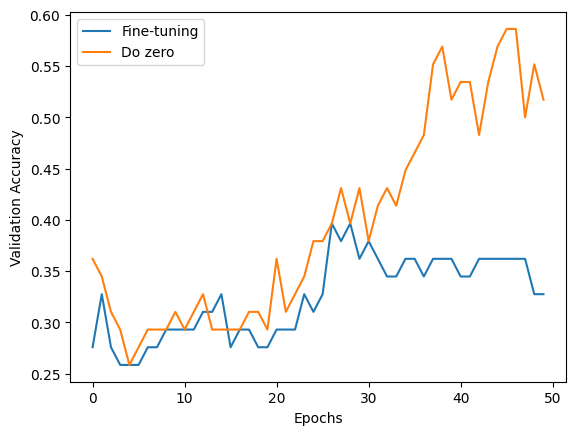

Melhor val_acc Fine-tuning: 0.3965517282485962
Melhor val_acc Do zero: 0.5862069129943848


In [11]:
# TODO: Treine e compare as duas abordagens

# history_ft_model = ft_model.fit(X2, y2, epochs=50, batch_size=32, validation_split=0.2,
#              callbacks=[tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)],
#              verbose=1)

# 1. Separe X2, y2 em treino/validação (80/20)

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

# 2. Treine model_ft no sujeito 2 (use EarlyStopping)
history_ft_model = ft_model.fit(X2_train, y2_train, validation_data=(X2_test, y2_test), epochs=50, batch_size=32, callbacks = [tf.keras.callbacks.EarlyStopping(patience=10)])
# 3. Treine um modelo DO ZERO no sujeito 2 para comparação
#    (crie um novo EEGNet com build_eegnet_annotated, compile e treine)

model_scratch = build_eegnet_annotated()
model_scratch.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss= 'sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history_model_scratch = model_scratch.fit(X2_train, y2_train, validation_data=(X2_test, y2_test), epochs = 50, batch_size = 32, callbacks = [tf.keras.callbacks.EarlyStopping(patience=10)])
# 4. Plote as curvas de val_accuracy das duas abordagens no mesmo gráfico

plt.plot(history_ft_model.history['val_accuracy'], label='Fine-tuning')
plt.plot(history_model_scratch.history['val_accuracy'], label='Do zero')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.show()
# 5. Imprima a melhor val_acc de cada abordagem
print(f"Melhor val_acc Fine-tuning: {max(history_ft_model.history['val_accuracy'])}")
print(f"Melhor val_acc Do zero: {max(history_model_scratch.history['val_accuracy'])}")

### 🔍 Reflexão

1. O fine-tuning convergiu mais rápido? Com acurácia maior? Interprete o resultado.
2. Se o fine-tuning **não** ajudou, o que isso sugere sobre as diferenças entre os sujeitos?
3. Em um cenário real de BCI (interface cérebro-computador para um paciente), qual das abordagens você usaria? Por quê?

> *Esta é uma questão de pesquisa em aberto na área. Você acabou de experimentar por que ela é difícil.*

---
## Exercício 8 — Desafio Final: Sua Variante do EEGNet

### 🤔 Pense Primeiro

Agora é sua vez de propor melhorias baseadas no que aprendeu:

1. O EEGNet original não tem mecanismo de **Attention**. Você usou Attention no seu notebook anterior para séries temporais. Faria sentido aqui? Em qual dimensão aplicaria?
2. E se você adicionasse um **terceiro bloco** com um SeparableConv de kernel maior (1, 32)? O que você esperaria que esse bloco capturasse?
3. O EEGNet usa `dropout_rate=0.5` fixo. Faria sentido aumentar o dropout em blocos mais profundos? Por quê?
4. Você poderia substituir a Dense final por um **Global Average Pooling** + Dense? Qual seria a diferença?

In [15]:
from tensorflow.keras.layers import GlobalAveragePooling2D, Multiply, AveragePooling2D, Reshape

In [20]:
# === Exercício 8 — Sua Variante do EEGNet ===

# Implemente uma modificação sua, com justificativa.
# Algumas sugestões (escolha uma ou combine):
#
# A) Adicionar um terceiro bloco conv
# B) Adicionar Channel Attention (SE Block) após os filtros espaciais
# C) Usar Bidirectional GRU após o segundo bloco conv
# D) Substituir SeparableConv por Conv1D equivalente e comparar parâmetros
# E) Sua ideia própria — justifique!

def build_my_eegnet(
    n_channels=22, n_times=1001, n_classes=4, sfreq=250,
    F1=8, D=2, F2=16, dropout_rate=0.5
):
    """
    Minha variante do EEGNet.
    
    Modificações:
    [TODO: Descreva aqui o que você vai mudar e por quê]
    """
    kern_len = sfreq // 2
    inputs = Input(shape=(1, n_channels, n_times), name='eeg_input')
    
    # TODO: Implemente sua variante aqui

    #-----------------------------------------------------------------------------------------------

    # BLOCK 1 - Filtro Temporal -> (olha o comportamento no tempo de cada 
    # eletrodo independentemente para explicitar "frequências importantes"
    # e cria filtros para essas "tentativas")
    
    x = Conv2D(
        kernel_size=(1, kern_len),
        filters= F1, use_bias= False,
        padding= 'same', name= 'temporal_conv',
        data_format='channels_first',
    )(inputs)

    x= BatchNormalization(axis= 1)(x)
    #normaliza ao longo dos canais (pra uma amplitude não afetar tanto a outra)
    
    #-----------------------------------------------------------------------------------------------
    
    # BLOCK 1.1 - Filtro Espacial -> Uni-dimensionaliza todos os filtros, criando 
    # "combinações" de canais que são relevantes para cada filtro temporal

    x= DepthwiseConv2D(
        kernel_size= (22, 1), use_bias= False, 
        data_format='channels_first', name= 'spatial_conv',
        depth_multiplier = D, depthwise_constraint= max_norm(1.0),
    )(x)

    x = BatchNormalization(axis= 1)(x)
    x = Activation("elu")(x)

    # ------------------------------------------------------------------------------------------------

    # BLOCK 1.2 - *CAMADA DE ATENÇÃO SE* (Squeeze-and-Excitation) -> Mecanismo
    # de atenção para reponder quais filtros espaciais são mais relevantes

    se = GlobalAveragePooling2D(data_format='channels_first')(x) #squeeze
    se = Dense(
        4, activation="relu"
    )(se)
    se = Dense(
        16, activation="sigmoid"
    )(se)
    se = Reshape((16, 1, 1))(se) #reshape para multiplicação
    x = Multiply()([x, se]) #excitation

    # x_shape = (batch, 16, 1 ,1001)
    # se_shape = (batch, 16, 1, 1)

    x = AveragePooling2D(pool_size= (1, 4), data_format='channels_first')(x)
    # x_shape = (batch, 16, 1 ,250)

    x = Dropout(rate= 0.5)(x)

    # BLOCK 2 - Separable Temporal -> É onde a rede aprende a combinar os filtros 
    # espaciais ao longo do tempo, criando "feature maps" espaço-temporais

    x = SeparableConv2D(
        filters = F2, padding= 'same',
        kernel_size = (1, 16), use_bias= False,
        data_format='channels_first', name= 'separable_conv',
    )(x)

    # x_shape = (batch, 16, 1 ,250) 
    # O que muda são os valores, não o shape. A rede refina os padrões temporais e mistura os filtros entre si.

    x = BatchNormalization(axis= 1)(x)
    x = Activation("elu")(x)
    x = AveragePooling2D(pool_size= (1, 8), data_format='channels_first')(x)
    x = Dropout(rate= dropout_rate)(x)

    # Classificador final

    x = Flatten()(x)
    outputs = Dense(
        n_classes, activation='softmax',
        kernel_constraint=max_norm(0.25), name='classifier'
    )(x)

    model = Model(inputs=inputs, outputs=outputs, name='my_eegnet')

    return model
# Após implementar, compare com o EEGNet original
my_model = build_my_eegnet()
my_model.summary()
print(f'\nParâmetros EEGNet original: {model.count_params():,}')
print(f'Parâmetros minha variante:  {my_model.count_params():,}')

print('Implemente build_my_eegnet() e descomente as linhas acima!')

Model: "my_eegnet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ eeg_input           │ (None, 1, 22,     │          0 │ -                 │
│ (InputLayer)        │ 1001)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temporal_conv       │ (None, 8, 22,     │      1,000 │ eeg_input[0][0]   │
│ (Conv2D)            │ 1001)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 22,     │         32 │ temporal_conv[0]… │
│ (BatchNormalizatio… │ 1001)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_conv        │ (None, 16, 1,     │        352 │ batch_normalizat… │
│ (DepthwiseConv2D)   │ 1001)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 1,     │         64 │ spatial_conv[0][… │
│ (BatchNormalizatio… │ 1001)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_10       │ (None, 16, 1,     │          0 │ batch_normalizat… │
│ (Activation)        │ 1001)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 16)        │          0 │ activation_10[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 4)         │         68 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 16)        │         80 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 16, 1, 1)  │          0 │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_2          │ (None, 16, 1,     │          0 │ activation_10[0]… │
│ (Multiply)          │ 1001)             │            │ reshape_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d_7 │ (None, 16, 1,     │          0 │ multiply_2[0][0]  │
│ (AveragePooling2D)  │ 250)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 16, 1,     │          0 │ average_pooling2… │
│                     │ 250)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv      │ (None, 16, 1,     │        512 │ dropout_5[0][0]   │
│ (SeparableConv2D)   │ 250)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 1,     │         64 │ separable_conv[0… │
│ (BatchNormalizatio… │ 250)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_11       │ (None, 16, 1,     │          0 │ batch_normalizat… │
│ (Activation)        │ 250)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d_8 │ (None, 16, 1, 31) │          0 │ activation_11[0]… │
│ (AveragePooling2D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 16, 1, 31) │          0 │ average_pooling2

 Total params: 4,160 (16.25 KB)

 Trainable params: 4,080 (15.94 KB)

 Non-trainable params: 80 (320.00 B)


Parâmetros EEGNet original: 4,012
Parâmetros minha variante:  4,160
Implemente build_my_eegnet() e descomente as linhas acima!


In [ ]:
_, acc_my = train_variant(build_my_eegnet, 'Minha variante EEGNet', epochs=100)

In [27]:
print(f'\nComparação:')
print(f'  EEGNet original: {acc_base:.4f}')
print(f'  Minha variante:  {acc_my:.4f}')
print(f'  Δ acurácia:      {acc_my - acc_base:+.4f}')


Comparação:
  EEGNet original: 0.7069
  Minha variante:  0.7931
  Δ acurácia:      +0.0862


### 🔍 Reflexão Final

1. Sua variante teve melhor ou pior desempenho? Se melhor, o que adicionou mais capacidade expressiva? Se pior, onde você acha que errou?
2. Mais parâmetros sempre significa melhor modelo em EEG? Por quê não?
3. O que você faria diferente se tivesse dados de todos os 9 sujeitos disponíveis?

---

## Resumo: O que você aprendeu

| Conceito | Aplicação em EEG |
|----------|------------------|
| **Tensor (n, 1, C, T)** | EEG como "imagem" espaço-temporal |
| **Conv2D temporal (1, kern)** | Aprende filtros de frequência (alpha, beta) |
| **DepthwiseConv2D (C, 1)** | Filtragem espacial eficiente por canal |
| **SeparableConv2D** | Temporal leve após combinação espaço-temporal |
| **AveragePooling** | Preserva energia oscilatória (não picos) |
| **max_norm** | Regularização implícita com poucos dados |
| **ELU** | Preserva gradientes para valores negativos |
| **Domain shift** | Cada sujeito EEG é um domínio diferente |
| **Fine-tuning** | Filtros temporais universais, espaciais individuais |
| **Ablation study** | Técnica para entender contribuição de cada componente |

> *Você agora entende não só **o que** o EEGNet faz, mas **por que** cada decisão foi tomada. Isso é o que diferencia um usuário de um pesquisador.*

In [28]:
from scipy.io import loadmat
from pathlib import Path

mat = loadmat(Path(r'C:\Users\pedro\Workspaces\EEG_learning\data\true_labels\A01E.mat'))
print({k: v for k, v in mat.items() if not k.startswith('_')})


{'classlabel': array([[1],
       [2],
       [2],
       [1],
       [2],
       [1],
       [2],
       [3],
       [2],
       [4],
       [1],
       [3],
       [2],
       [1],
       [4],
       [4],
       [4],
       [4],
       [4],
       [1],
       [3],
       [2],
       [1],
       [1],
       [3],
       [4],
       [1],
       [3],
       [3],
       [3],
       [1],
       [2],
       [1],
       [2],
       [2],
       [1],
       [2],
       [3],
       [2],
       [3],
       [3],
       [4],
       [3],
       [3],
       [4],
       [4],
       [4],
       [4],
       [4],
       [3],
       [2],
       [1],
       [1],
       [2],
       [3],
       [4],
       [2],
       [3],
       [1],
       [1],
       [1],
       [4],
       [2],
       [2],
       [1],
       [1],
       [3],
       [1],
       [2],
       [4],
       [4],
       [3],
       [1],
       [4],
       [4],
       [2],
       [4],
       [4],
       [2],
       [1],
       [2],
       [3],
 

O modelo treinado está salvo em:

models\eegnet_subject1.keras

Ele foi salvo no notebook eegnet_motor_imagery.ipynb, na seção "8. Save & Load Model", com este código:


model_path = MODELS_DIR / f'eegnet_subject{SUBJECT_ID}.keras'
model.save(model_path)
Para carregar em outro lugar:


import tensorflow as tf
model = tf.keras.models.load_model(r'models\eegnet_subject1.keras')